# Лабораторная работа №3: Деревья решений

## Предсказание выживаемости пассажиров Титаника

---

## 0. О датасете Titanic

### История
15 апреля 1912 года затонул британский пассажирский лайнер **«Титаник»** после столкновения с айсбергом. Из 2224 пассажиров и членов экипажа погибло 1502 человека.

### Задача
Построить модель, которая предсказывает **выжил ли пассажир** на основе его характеристик.

### Признаки
| Признак | Описание |
|---------|----------|
| `survived` | **Целевая переменная**: 1 = выжил, 0 = погиб |
| `pclass` | Класс каюты: 1 = первый, 2 = второй, 3 = третий |
| `sex` | Пол: male = мужчина, female = женщина |
| `age` | Возраст в годах |
| `fare` | Стоимость билета в фунтах |

### Интересный факт
- Выживаемость женщин: **~74%**
- Выживаемость мужчин: **~19%**

Принцип «женщины и дети первыми» сыграл решающую роль при эвакуации.

## 1. Теоретический блок

### Что такое дерево решений?

Представьте, что вы играете в игру «Угадай персонажа». Вы задаёте вопросы: «Это мужчина?», «Ему больше 30?», «Он из первого класса?» — и в конце делаете вывод. Дерево решений работает точно так же!

**Дерево решений** — это алгоритм, который:
1. Выбирает самый информативный признак
2. Разбивает данные на группы по этому признаку
3. Повторяет процесс для каждой группы
4. В листьях дерева — предсказания (выжил/погиб)

### Интуиция: как выбрать признак для разбиения?

Представьте коробку с красными и синими шарами. Вы хотите разделить их на две коробки так, чтобы в каждой было как можно больше шаров одного цвета.

**Хорошее разбиение:** в левой коробке 9 красных и 1 синий, в правой — 1 красный и 9 синих.

**Плохое разбиение:** в каждой коробке по 5 красных и 5 синих.

Критерии (Gini и Энтропия) — это способ измерить «чистоту» разбиения числом.

---

### Энтропия Шеннона

$$H(p) = -p \log_2(p) - (1-p) \log_2(1-p)$$

Где $p$ — доля объектов класса «1» (выживших) в узле.

| Ситуация | p | Энтропия | Интерпретация |
|----------|---|----------|---------------|
| Все погибли | 0 | **0** | Полная определённость |
| Все выжили | 1 | **0** | Полная определённость |
| Поровну | 0.5 | **1** | Максимальная неопределённость |

**Интуиция:** Энтропия = 0 означает, что мы точно знаем ответ. Энтропия = 1 означает, что мы совсем не уверены (монетка 50/50).

---

### Gini Impurity

$$\text{Gini} = 1 - p^2 - (1-p)^2 = 2p(1-p)$$

| Ситуация | p | Gini | Интерпретация |
|----------|---|------|---------------|
| Все погибли | 0 | **0** | Чистый узел |
| Все выжили | 1 | **0** | Чистый узел |
| Поровну | 0.5 | **0.5** | Максимальная примесь |

**Интуиция:** Gini — это вероятность ошибиться, если предсказать класс случайно пропорционально их долям.

---

### Information Gain (Прирост информации)

$$IG = H(\text{родитель}) - \sum_{i} \frac{n_i}{n} H(\text{ребёнок}_i)$$

**Интуиция:** IG показывает, насколько уменьшилась неопределённость после разбиения.

- IG = 0 — разбиение бесполезно
- IG > 0 — разбиение полезно
- Чем больше IG, тем лучше разбиение

**Алгоритм выбора признака:**
1. Для каждого признака рассчитать IG при разбиении по нему
2. Выбрать признак с максимальным IG

In [53]:
# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
print("Библиотеки загружены!")

Библиотеки загружены!


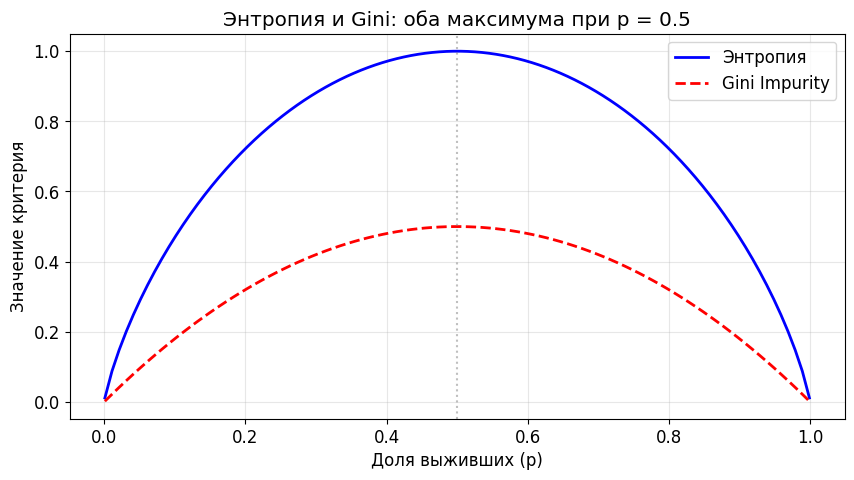

In [54]:
# Визуализация: сравнение Энтропии и Gini
p = np.linspace(0.001, 0.999, 100)

entropy = -p * np.log2(p) - (1-p) * np.log2(1-p)
gini = 2 * p * (1-p)

plt.figure(figsize=(10, 5))
plt.plot(p, entropy, 'b-', linewidth=2, label='Энтропия')
plt.plot(p, gini, 'r--', linewidth=2, label='Gini Impurity')
plt.xlabel('Доля выживших (p)')
plt.ylabel('Значение критерия')
plt.title('Энтропия и Gini: оба максимума при p = 0.5')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axvline(x=0.5, color='gray', linestyle=':', alpha=0.5)
plt.show()

---
## 2. Подготовка данных

In [55]:
# Загрузка и подготовка данных
df = sns.load_dataset('titanic')
df = df[['survived', 'pclass', 'sex', 'age', 'fare']].dropna()
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

print(f"Размер датасета: {df.shape[0]} пассажиров")
df.head(10)

Размер датасета: 714 пассажиров


,survived,pclass,sex,age,fare
0,0,3,0,22.0,7.2500
1,1,1,1,38.0,71.2833
2,1,3,1,26.0,7.9250
3,1,1,1,35.0,53.1000
4,0,3,0,35.0,8.0500
6,0,1,0,54.0,51.8625
7,0,3,0,2.0,21.0750
8,1,3,1,27.0,11.1333
9,1,2,1,14.0,30.0708
10,1,3,1,4.0,16.7000


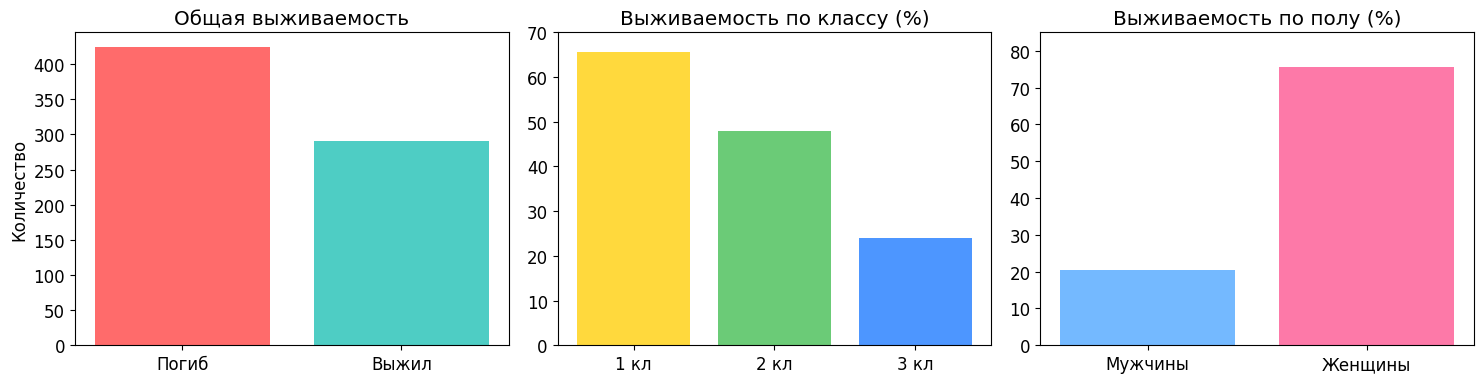

In [56]:
# EDA: Выживаемость по классам и полу
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Общая выживаемость
survival_counts = df['survived'].value_counts()
axes[0].bar(['Погиб', 'Выжил'], [survival_counts[0], survival_counts[1]], color=['#ff6b6b', '#4ecdc4'])
axes[0].set_title('Общая выживаемость')
axes[0].set_ylabel('Количество')

# По классу
survival_by_class = df.groupby('pclass')['survived'].mean() * 100
axes[1].bar(['1 кл', '2 кл', '3 кл'], survival_by_class.values, color=['#ffd93d', '#6bcb77', '#4d96ff'])
axes[1].set_title('Выживаемость по классу (%)')
axes[1].set_ylim(0, 70)

# По полу
survival_by_sex = df.groupby('sex')['survived'].mean() * 100
axes[2].bar(['Мужчины', 'Женщины'], survival_by_sex.values, color=['#74b9ff', '#fd79a8'])
axes[2].set_title('Выживаемость по полу (%)')
axes[2].set_ylim(0, 85)

plt.tight_layout()
plt.show()

---
## 3. Задание: Ручной расчёт критерия разбиения

### Определение варианта

**Формула:** `ID = (№ по списку - 1) % 20 + 1`

| Вариант | Критерий |
|---------|----------|
| Нечётный (1, 3, 5, ...) | **Энтропия** |
| Чётный (2, 4, 6, ...) | **Gini** |

In [57]:
# ============================================
# ВАЖНО: Замените на ваш номер по списку!
# ============================================
NOMER_V_SPISKE = 1  # ← Замените на ваш номер

# Вычисление ID варианта (НЕ ИЗМЕНЯЙТЕ)
ID = (NOMER_V_SPISKE - 1) % 20 + 1
CRITERION = 'gini' if ID % 2 == 0 else 'entropy'

print(f"ID варианта: {ID}")
print(f"Критерий: {CRITERION.upper()}")

ID варианта: 1
Критерий: ENTROPY


In [58]:
# Получение вашей подвыборки (случайная выборка с seed = ID)
np.random.seed(ID)
subset = df.sample(n=15, random_state=ID).copy().reset_index(drop=True)

print(f"Ваша подвыборка (seed={ID}):\n")
subset

Ваша подвыборка (seed=1):



,survived,pclass,sex,age,fare
0,1,1,1,15.0,211.3375
1,0,3,0,7.0,29.1250
2,1,2,1,33.0,26.0000
3,1,2,1,14.0,30.0708
4,0,3,0,21.0,8.0500
5,0,2,0,42.0,13.0000
6,1,2,1,23.0,13.7917
7,0,1,0,56.0,26.5500
8,0,2,0,39.0,13.0000
9,0,2,0,24.0,13.0000


---
### Задание 3.1: Статистика подвыборки

Посчитайте базовую статистику для вашей подвыборки.

**Ответ:**

- Всего пассажиров: ____
- Выжило: ____
- Погибло: ____
- Доля выживших (p): ____

---
### Задание 3.2: Расчёт критерия для корневого узла

Рассчитайте критерий (Gini или Энтропию) для всей подвыборки.

**Формулы:**
- Энтропия: $H = -p \log_2(p) - (1-p) \log_2(1-p)$
- Gini: $G = 2 \cdot p \cdot (1-p)$

**Расчёт (покажите формулу с подставленными числами):**

```
(напишите здесь расчёт)
```

**Ответ:** Критерий(root) = ____

---
### Задание 3.3: Разбиение по признаку `sex`

Разбейте данные на две группы по полу и рассчитайте критерий для каждой.

**Ответы:**

| Группа | Кол-во | Выжило | p (доля выживших) |
|--------|--------|--------|-------------------|
| sex=0 (мужчины) | ____ | ____ | ____ |
| sex=1 (женщины) | ____ | ____ | ____ |

**Расчёт:**

```
Критерий(left, мужчины) = ...
Критерий(right, женщины) = ...
```

**Ответы:**
- Критерий(left) = ____
- Критерий(right) = ____

---
### Задание 3.4: Information Gain для `sex`

Рассчитайте взвешенный критерий после разбиения и Information Gain.

$$IG = \text{Критерий}(root) - \frac{n_{left}}{n} \cdot \text{Критерий}(left) - \frac{n_{right}}{n} \cdot \text{Критерий}(right)$$

**Расчёт:**

```
IG(sex) = ...
```

**Ответ:** IG(sex) = ____

---
### Задание 3.5: Разбиение по признаку `pclass`

Разбейте данные на три группы по классу каюты.

**Ответы:**

| Группа | Кол-во | Выжило | p | Критерий |
|--------|--------|--------|---|----------|
| pclass=1 | ____ | ____ | ____ | ____ |
| pclass=2 | ____ | ____ | ____ | ____ |
| pclass=3 | ____ | ____ | ____ | ____ |

**IG(pclass) = ____**

---
### Задание 3.6: Выбор лучшего признака

Сравните IG для двух признаков и выберите лучший для корня дерева.

**Ответы:**

| Признак | IG |
|---------|-----|
| sex | ____ |
| pclass | ____ |

**Лучший признак для корня дерева:** ____

---
### Таблица ответов для отчёта

Скопируйте эту таблицу в отчёт и заполните:

| Параметр | Значение |
|----------|----------|
| ID варианта | |
| Критерий | Gini / Энтропия |
| Всего пассажиров в подвыборке | |
| p (доля выживших в root) | |
| Критерий(root) | |
| Критерий(left), после sex | |
| Критерий(right), после sex | |
| IG(sex) | |
| IG(pclass) | |
| Лучший признак для корня | sex / pclass |

---
## 4. Построение дерева решений (sklearn)

Теперь построим дерево с помощью библиотеки sklearn.

In [59]:
# Подготовка данных (90% датасета, seed = ID варианта)
df_sample = df.sample(frac=0.9, random_state=ID)
X = df_sample[['pclass', 'sex', 'age', 'fare']]
y = df_sample['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Seed выборки: {ID}")
print(f"Размер выборки: {len(df_sample)} из {len(df)} (90%)")
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Seed выборки: 1
Размер выборки: 643 из 714 (90%)
Train: 514, Test: 129


In [60]:
# Обучение дерева с вашим критерием
model = DecisionTreeClassifier(max_depth=3, criterion=CRITERION, random_state=42)
model.fit(X_train, y_train)

train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc = accuracy_score(y_test, model.predict(X_test))

print(f"Критерий: {CRITERION}")
print(f"Train accuracy: {train_acc:.3f}")
print(f"Test accuracy: {test_acc:.3f}")

Критерий: entropy
Train accuracy: 0.819
Test accuracy: 0.798


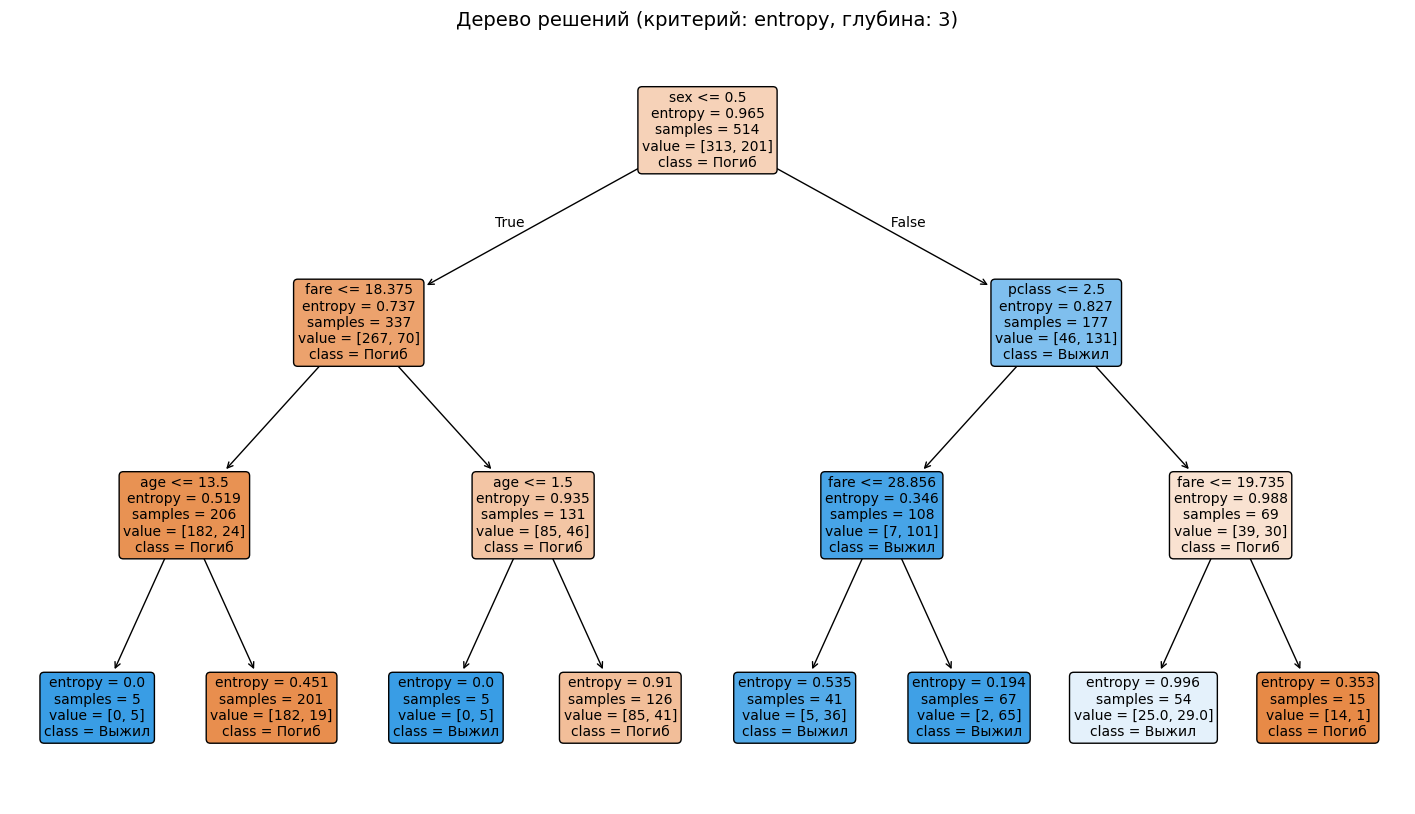

In [61]:
# Визуализация дерева
plt.figure(figsize=(18, 10))
plot_tree(model, 
          feature_names=['pclass', 'sex', 'age', 'fare'],
          class_names=['Погиб', 'Выжил'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title(f'Дерево решений (критерий: {CRITERION}, глубина: 3)', fontsize=14)
plt.show()

### Задание 4.1: Интерпретация дерева

Посмотрите на построенное дерево и запишите **3 правила** в формате IF-THEN.

Пример:
```
ЕСЛИ sex <= 0.5 (мужчина) И age <= 6.5 ТО выжил
```

**Ваши правила:**

1. ```
   ЕСЛИ ... ТО ...
   ```

2. ```
   ЕСЛИ ... ТО ...
   ```

3. ```
   ЕСЛИ ... ТО ...
   ```

---
## 5. Feature Importance

In [62]:
# Важность признаков
importance = pd.DataFrame({
    'Признак': ['pclass', 'sex', 'age', 'fare'],
    'Важность': model.feature_importances_
}).sort_values('Важность', ascending=False)

print("Важность признаков:")
print(importance.to_string(index=False))

Важность признаков:
Признак  Важность
    sex  0.515876
 pclass  0.207043
   fare  0.154926
    age  0.122155


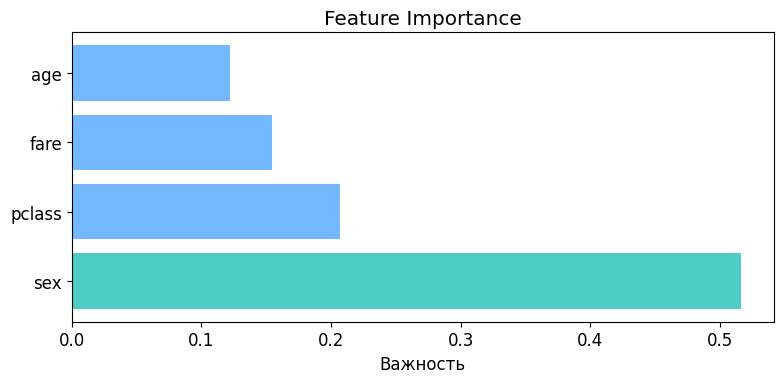

In [63]:
# Визуализация важности
plt.figure(figsize=(8, 4))
colors = ['#4ecdc4' if imp == importance['Важность'].max() else '#74b9ff' for imp in importance['Важность']]
plt.barh(importance['Признак'], importance['Важность'], color=colors)
plt.xlabel('Важность')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

**Вопрос:** Совпадает ли признак с наибольшей важностью с вашим ручным расчётом лучшего признака?

**Ответ:** ____

**Если не совпадает, почему?**

```
(напишите здесь)
```

---
## 6. Предсказание для новых пассажиров

Для каждого пассажира:
1. Пройдите по дереву вручную (посмотрите на визуализацию выше)
2. Запишите путь (какие условия проверялись)
3. Запишите прогноз
4. Проверьте с помощью кода ниже

In [64]:
# Данные пассажиров
passengers = pd.DataFrame({
    'pclass': [1, 3, 2, 1],
    'sex': [1, 0, 1, 0],  # 0=male, 1=female
    'age': [30, 25, 5, 50],
    'fare': [100, 10, 30, 50]
}, index=['А', 'Б', 'В', 'Г'])

print("Данные пассажиров:")
passengers

Данные пассажиров:


,pclass,sex,age,fare
А,1,1,30,100
Б,3,0,25,10
В,2,1,5,30
Г,1,0,50,50


### Ручное предсказание

Заполните таблицу, пройдя по дереву вручную:

| Пассажир | pclass | sex | age | Путь по дереву | Прогноз |
|----------|--------|-----|-----|----------------|---------|
| А | 1 | 1 (жен) | 30 | | |
| Б | 3 | 0 (муж) | 25 | | |
| В | 2 | 1 (жен) | 5 | | |
| Г | 1 | 0 (муж) | 50 | | |

In [65]:
# Предсказания модели
predictions = model.predict(passengers)
probabilities = model.predict_proba(passengers)

print("Предсказания модели:\n")
for name, pred, prob in zip(passengers.index, predictions, probabilities):
    result = "ВЫЖИЛ" if pred == 1 else "ПОГИБ"
    confidence = prob[pred] * 100
    print(f"Пассажир {name}: {result} (уверенность: {confidence:.1f}%)")

Предсказания модели:

Пассажир А: ВЫЖИЛ (уверенность: 97.0%)
Пассажир Б: ПОГИБ (уверенность: 90.5%)
Пассажир В: ВЫЖИЛ (уверенность: 97.0%)
Пассажир Г: ПОГИБ (уверенность: 67.5%)


**Совпали ли ваши предсказания с моделью?** ____

---
## 7. Исследование переобучения (Overfitting)

In [66]:
# Обучаем деревья с разной глубиной (на той же выборке 90%)
depths = range(1, 16)
train_scores = []
test_scores = []

for depth in depths:
    clf = DecisionTreeClassifier(max_depth=depth, criterion=CRITERION, random_state=42)
    clf.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, clf.predict(X_train)))
    test_scores.append(accuracy_score(y_test, clf.predict(X_test)))

# Результаты
print(f"Seed выборки: {ID}")
print("\nГлубина | Train | Test  | Разница")
print("-" * 35)
for d, tr, te in zip(depths, train_scores, test_scores):
    print(f"   {d:2d}   | {tr:.3f} | {te:.3f} | {tr-te:+.3f}")

Seed выборки: 1

Глубина | Train | Test  | Разница
-----------------------------------
    1   | 0.774 | 0.775 | -0.001
    2   | 0.792 | 0.806 | -0.014
    3   | 0.819 | 0.798 | +0.021
    4   | 0.835 | 0.814 | +0.021
    5   | 0.858 | 0.798 | +0.060
    6   | 0.874 | 0.783 | +0.091
    7   | 0.897 | 0.744 | +0.153
    8   | 0.911 | 0.760 | +0.151
    9   | 0.926 | 0.760 | +0.166
   10   | 0.938 | 0.760 | +0.178
   11   | 0.959 | 0.736 | +0.223
   12   | 0.969 | 0.767 | +0.201
   13   | 0.979 | 0.752 | +0.227
   14   | 0.981 | 0.760 | +0.221
   15   | 0.984 | 0.744 | +0.240


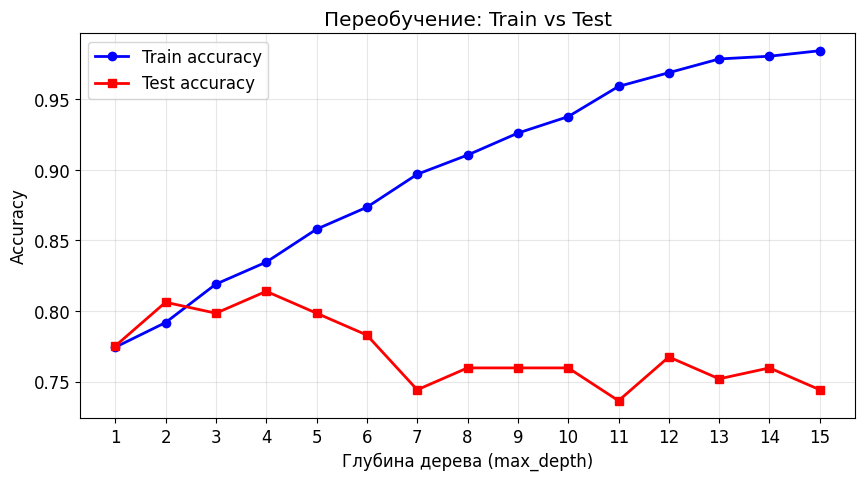

Максимальный Test accuracy: 0.814


In [68]:
# График
plt.figure(figsize=(10, 5))
plt.plot(depths, train_scores, 'b-o', label='Train accuracy', linewidth=2)
plt.plot(depths, test_scores, 'r-s', label='Test accuracy', linewidth=2)
plt.xlabel('Глубина дерева (max_depth)')
plt.ylabel('Accuracy')
plt.title('Переобучение: Train vs Test')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(depths)

plt.show()

print(f"Максимальный Test accuracy: {max(test_scores):.3f}")

### Вопросы:

1. **На какой глубине test accuracy максимален?** ____

2. **На какой глубине начинается переобучение?** (train растёт, test падает) ____

3. **Какую глубину вы бы выбрали для финальной модели?** ____

## 8. Итоговые вопросы

### Теория дерева

**Вопрос 1:** Какое максимальное количество листьев может быть у дерева глубины 3? А глубины 5?

*Подсказка: каждый узел делится на 2 потомка.*

**Ответ:**
```
...
```

**Вопрос 2:** Почему деревья решений не требуют нормализации признаков (в отличие от линейных моделей)?

**Ответ:**
```
...
```

**Вопрос 3:** Что произойдёт с деревом, если в данных появится выброс — пассажир с fare=10000?

**Ответ:**
```
...
```

---
### Интерпретация результатов

**Вопрос 4:** Посмотрите на ваше дерево. Какой путь от корня до листа даёт наивысшую вероятность выживания?

*Опишите путь: какие условия проверяются?*

**Ответ:**
```
...
```

**Вопрос 5:** Почему признак `age` используется деревом только для мужчин, но не для женщин?

*Подсказка: посмотрите на структуру дерева.*

**Ответ:**
```
...
```

**Вопрос 6:** Какой признак оказался наименее важным (feature importance близко к 0)? Почему?

**Ответ:**
```
...
```

---
### Что если...

**Вопрос 7:** Как изменится дерево, если удалить признак `sex` из данных?

**Ответ:**
```
...
```

**Вопрос 8:** Какой критерий (Gini или Entropy) лучше подходит для задачи с сильным дисбалансом классов — например, 99% нормальных транзакций и 1% мошеннических?

**Ответ:**
```
...
```

---
### Бизнес-контекст

**Вопрос 9:** Можно ли использовать это дерево для принятия решений о страховке жизни? Какие есть ограничения?

**Ответ:**
```
...
```

**Вопрос 10:** В чём преимущество дерева решений перед «чёрным ящиком» нейросети для бизнес-приложений?

**Ответ:**
```
...
```